In [1]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = pd.read_csv(r'C:\DATA ANALYSIS AND DATA SCIENCE PROJECTS\Multi Scale Energy Stress Analysis\code\anamoly detection and interpretation\forecasting based anomaly detection\forecasting_feature_set.csv')

# TARGET (t+1)
df['target'] = df['net_load_mw'].shift(-1)
df = df.dropna().reset_index(drop=True)

split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df  = df.iloc[split_index:]

X_train = train_df.drop(columns=['target'])
y_train = train_df['target']

X_test = test_df.drop(columns=['target'])
y_test = test_df['target']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3]
}

tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

best_model = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

y_pred = best_model.predict(X_test_scaled)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'subsample': 0.8, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 1.0}


In [2]:
# METRICS
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
epsilon = 1e-6
mape = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon))) * 100

print("MODEL PERFORMANCE METRICS")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

errors = y_test - y_pred
print("\nError Summary:")
print(f"Mean Error      : {np.mean(errors):.4f}")
print(f"Std Error       : {np.std(errors):.4f}")
print(f"Max Error       : {np.max(np.abs(errors)):.4f}")

MODEL PERFORMANCE METRICS
RMSE : 214.0807
MAE  : 142.6835
R²   : 0.9988
MAPE : 0.82%

Error Summary:
Mean Error      : -2.0223
Std Error       : 214.0712
Max Error       : 3469.6556


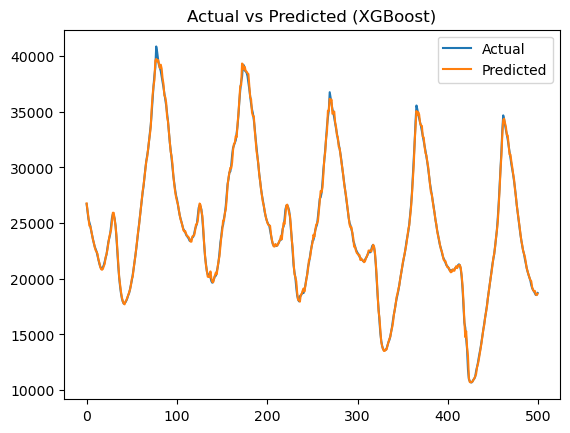

In [3]:
start = 10000
end = 10500

plt.figure()
plt.plot(y_test.values[start:end], label="Actual")
plt.plot(y_pred[start:end], label="Predicted")
plt.title("Actual vs Predicted (XGBoost)")
plt.legend()
plt.show()

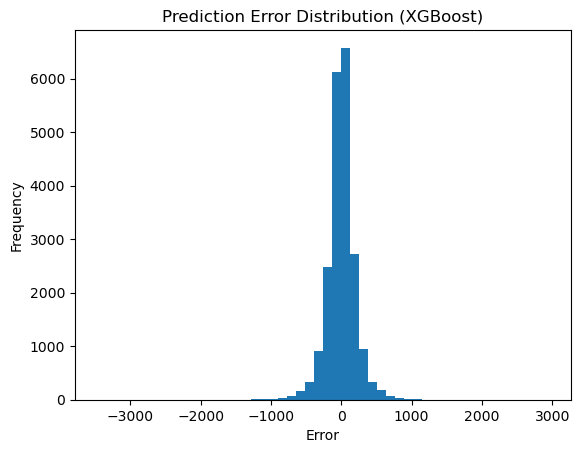

In [4]:
# Error Distribution
plt.figure()
plt.hist(errors, bins=50)
plt.title("Prediction Error Distribution (XGBoost)")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

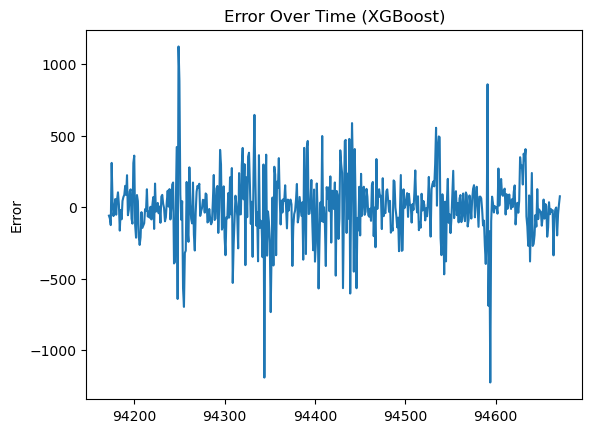

In [5]:
# Error over time
plt.figure()
plt.plot(errors[start:end])
plt.title("Error Over Time (XGBoost)")
plt.ylabel("Error")
plt.show()


Top 10 Important Features:
net_load_mw                    0.979098
net_load_ramp                  0.007846
hour_sin                       0.002248
demand_lag_1h                  0.001954
solar_ramp                     0.001633
demand_avg_mw                  0.001471
solar_gen_mw                   0.000804
demand_ramp                    0.000548
total_renewable_penetration    0.000408
month_sin                      0.000401
dtype: float32


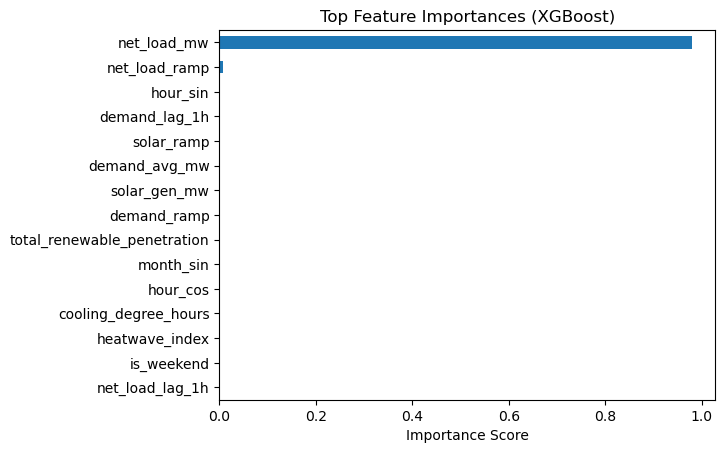

In [6]:
# FEATURE IMPORTANCE
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print("\nTop 10 Important Features:")
print(importances.head(10))

top_n = 15
plt.figure()
importances.head(top_n).sort_values().plot(kind='barh')
plt.title("Top Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.show()